In [1]:
import config_paths_ipynb

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_columns", 50)
import numpy as np

from ibd_biom_glycoda.config import DATASETS_DIR, FIGURE_DIR
from ibd_biom_glycoda.data.dataset import load_dataset_excel, prepare_ibd_dataset
from ibd_biom_glycoda.analysis.glycanage import plot_age_acceleration_by_cohort
from ibd_biom_glycoda.plotting.style import rcparams_aga, generate_semantic_colors, create_figure_with_panels, save_figure_aga_compliant


# Load and preprocess data
fname = 'ibd_biom_prospective_dataset_baseline.xlsx'
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)
print('Loaded IBD dataset with shape:', df_ibd.shape)

# Specify dataset
BINARY = False

CONTROLS = ['HC', 'SC']
CASES = ['CD', 'UC']
DATASET = '_'.join(CONTROLS) + '__' + '_'.join(CASES)
print(f"Dataset: {DATASET}")

df_multi, coda_cols = prepare_ibd_dataset(df_ibd, binary=BINARY)
print('Prepared dataset with shape:', df_multi.shape)
print('Dropped rows:', df_ibd.shape[0] - df_multi.shape[0]) # sanity check

PALETTE = 'okabe_ito'
rcparams_aga(palette=PALETTE)
DISEASE_COLORS, COHORT_COLORS, METRICS_COLORS, SUBGROUP_COLORS, PROCESSOR_COLORS, MODEL_COLORS = generate_semantic_colors(palette=PALETTE, preview=False)

Notebook config loaded. Project root added: C:\Users\konst\GitProjects\ibd-biom-glycoda
Loaded IBD dataset with shape: (1449, 31)
Dataset: HC_SC__CD_UC
Dropped 0 low abundant GP columns: []
Retained 24 GP columns: ['GP1_FA1', 'GP2_A2', 'GP3_A2B', 'GP4_FA2', 'GP5_M5', 'GP6_FA2B', 'GP7_A2G1', 'GP8_FA2_6_G1', 'GP9_FA2_3_G1', 'GP10_FA2_6_BG1', 'GP11_FA2_3_BG1', 'GP12_A2G2', 'GP13_A2BG2', 'GP14_FA2G2', 'GP15_FA2BG2', 'GP16_FA2G1S1', 'GP17_A2G2S1', 'GP18_FA2G2S1', 'GP19_FA2BG2S1', 'GP20__', 'GP21_A2G2S2', 'GP22_A2BG2S2', 'GP23_FA2G2S2', 'GP24_FA2BG2S2']
Prepared dataset with shape: (1367, 31)
Dropped rows: 82


In [2]:
# Summary table for age acceleration by cohort/panel
from ibd_biom_glycoda.analysis.glycanage import calculate_age_acceleration

cohort_order = ['UK', 'US', 'IT', 'NL']

df_delta = calculate_age_acceleration(
    df_multi,
    glycan_age_col="GlycanAge",
    chron_age_col="Age",
    out_col="AgeAcceleration",
    inplace=False
)

base_cols = ["Cohort", "DISEASE", "AgeAcceleration"]
summary_base = df_delta[base_cols].dropna(subset=["AgeAcceleration"]).copy()

# Multiclass summary
summary_mult = (
    summary_base
    .groupby(["Cohort", "DISEASE"], as_index=False)
    .agg(n=("AgeAcceleration", "size"),
         median_AA=("AgeAcceleration", "median"))
    .assign(panel="multiclass")
)

# Binary summary
binary_mapping = {"HC": "Non-IBD", "IBS": "Non-IBD", "CD": "IBD", "UC": "IBD"}
summary_bin = summary_base.copy()
summary_bin["DISEASE"] = summary_bin["DISEASE"].map(binary_mapping)
summary_bin = (
    summary_bin
    .groupby(["Cohort", "DISEASE"], as_index=False)
    .agg(n=("AgeAcceleration", "size"),
         median_AA=("AgeAcceleration", "median"))
    .assign(panel="binary")
)

summary_table = pd.concat([summary_mult, summary_bin], ignore_index=True)

# Order cohorts and tidy columns
summary_table["Cohort"] = pd.Categorical(
    summary_table["Cohort"], categories=cohort_order, ordered=True
)
summary_table = summary_table.sort_values(["Cohort", "panel", "DISEASE"]).reset_index(drop=True)

summary_table

,Cohort,DISEASE,n,median_AA,panel
0,UK,IBD,244,13.467996,binary
1,UK,Non-IBD,88,4.118703,binary
2,UK,CD,112,18.236134,multiclass
3,UK,HC,88,4.118703,multiclass
4,UK,SC,74,8.846227,multiclass
5,UK,UC,132,10.480219,multiclass
6,US,IBD,216,11.870251,binary
7,US,Non-IBD,36,6.628662,binary
8,US,CD,152,13.009255,multiclass
9,US,HC,36,6.628662,multiclass


In [3]:
# Significance table for cohort-wise comparisons
from ibd_biom_glycoda.analysis.glycanage import compute_fdr_adjusted_pvals, map_padj_to_confidence

multiclass_comparisons = [("IBS", "HC"), ("CD", "HC"), ("UC", "HC")]
binary_comparisons = [("IBD", "Non-IBD")]

records = []
for cohort in cohort_order:
    cohort_df = summary_base[summary_base["Cohort"] == cohort].copy()
    if cohort_df.empty:
        continue

    # multiclass
    p_adj_map_multi = compute_fdr_adjusted_pvals(
        df=cohort_df,
        disease_col="DISEASE",
        value_col="AgeAcceleration",
        comparisons=multiclass_comparisons,
        fdr_method="fdr_bh",
        alternative="two-sided"
    )
    for case, ctrl in multiclass_comparisons:
        p_adj = p_adj_map_multi.get((case, ctrl), np.nan)
        records.append({
            "Cohort": cohort,
            "panel": "multiclass",
            "comparison": f"{case} vs {ctrl}",
            "p_adj": p_adj,
            "significance": map_padj_to_confidence(p_adj)
        })

    # binary
    tmp = cohort_df[cohort_df["DISEASE"].isin(binary_mapping.keys())].copy()
    tmp["DISEASE"] = tmp["DISEASE"].map(binary_mapping)
    p_adj_map_bin = compute_fdr_adjusted_pvals(
        df=tmp,
        disease_col="DISEASE",
        value_col="AgeAcceleration",
        comparisons=binary_comparisons,
        fdr_method="fdr_bh",
        alternative="two-sided"
    )
    p_adj_bin = p_adj_map_bin.get(("IBD", "Non-IBD"), np.nan)
    records.append({
        "Cohort": cohort,
        "panel": "binary",
        "comparison": "IBD vs Non-IBD",
        "p_adj": p_adj_bin,
        "significance": map_padj_to_confidence(p_adj_bin)
    })

significance_table = pd.DataFrame.from_records(records)
significance_table["Cohort"] = pd.Categorical(
    significance_table["Cohort"], categories=cohort_order, ordered=True
)
significance_table = significance_table.sort_values(["Cohort", "panel", "comparison"]).reset_index(drop=True)

significance_table

,Cohort,panel,comparison,p_adj,significance
0,UK,binary,IBD vs Non-IBD,7.086026e-09,***
1,UK,multiclass,CD vs HC,7.461031e-11,***
2,UK,multiclass,IBS vs HC,NaN,na
3,UK,multiclass,UC vs HC,1.183427e-04,***
4,US,binary,IBD vs Non-IBD,7.932210e-04,***
5,US,multiclass,CD vs HC,8.840593e-04,***
6,US,multiclass,IBS vs HC,NaN,na
7,US,multiclass,UC vs HC,1.904664e-02,**
8,IT,binary,IBD vs Non-IBD,2.242077e-16,***
9,IT,multiclass,CD vs HC,1.510814e-17,***


✓ CMYK TIFF created


(None,
 'C:\\Users\\konst\\GitProjects\\ibd-biom-glycoda\\figures\\figure 2.tiff')

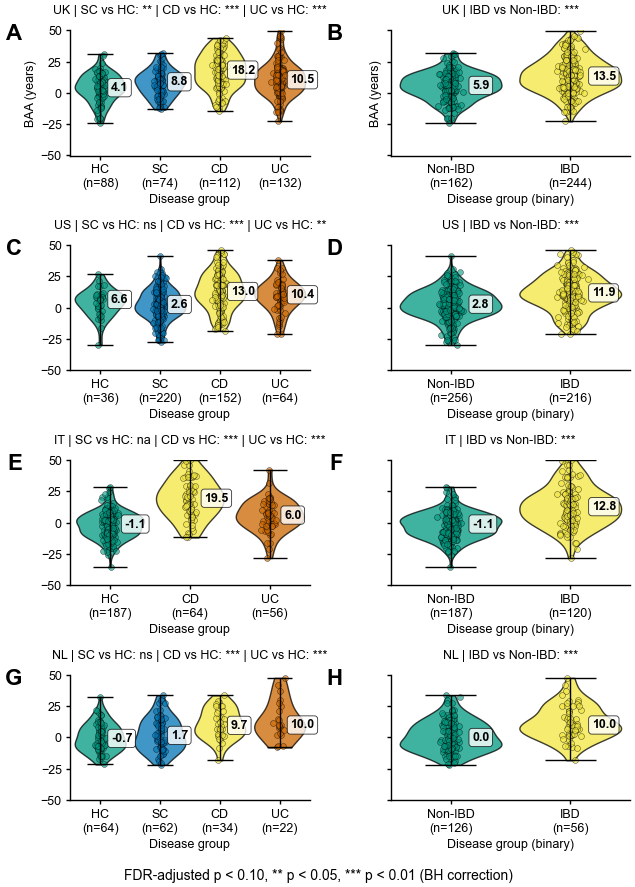

In [ ]:
# Create AGA-compliant figure and axes (4 cohorts × 2 panels)
fig, axes = create_figure_with_panels(
    figsize=(6.5, 9.0),   # within (7, 9)
    layout=(4, 2),
    sharey=True
)

# Render onto those axes
note = plot_age_acceleration_by_cohort(
    df=df_multi,
    axes=axes,
    cohort_col="Cohort",
    disease_col="DISEASE",
    glycan_age_col="GlycanAge",
    chron_age_col="Age",
    age_acc_col="AgeAcceleration",
    disease_colors=DISEASE_COLORS,
    cohort_order=['UK', 'US', 'IT', 'NL'],
    show_ns=True,
    show_na=True,
    seed=0
)

# Add global figure note
fig.text(
    0.5, 0.01,
    note,
    ha="center", va="bottom",
    fontsize=9, fontfamily="sans-serif"
)

# Tight layout
fig.tight_layout(rect=[0, 0.03, 1, 1])

# Save with AGA style
_, _ = save_figure_aga_compliant(
    fig=fig,
    path=FIGURE_DIR,
    filename='figure 2',
    format='tiff',
    dpi=500
)